# Pose-Based Human Activity Classifier
**Computer Vision — Complex Computing Problem (CLO-3)**

This notebook implements a pose-based activity classification pipeline:
1. Extract body keypoints using MediaPipe Pose, apply smoothing, and draw the skeleton on each frame.
2. Compute knee, hip, and elbow joint angles across all frames and detect activity transitions.
3. Classify each frame as standing or sitting using angle thresholds, and measure accuracy against ground truth.

### Video source
Own pre-recorded clip: `activity.mp4` (~20.5 s, 613 frames, 30 fps) — a single person repeatedly standing up and sitting down.

## Setup
Imports and configuration (paths, smoothing parameters, angle thresholds).

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp
from scipy.signal import savgol_filter
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---- Configuration ----
VIDEO_PATH   = "activity.mp4"
OUT_DIR      = "outputs"
GT_CSV       = "ground_truth.csv"   # manually-labeled per-frame labels
SMOOTH_WIN   = 11                   # Savitzky-Golay window (odd)
SMOOTH_POLY  = 3                    # Savitzky-Golay polynomial order
KNEE_THRESH  = 130                  # deg: standing if knee angle exceeds this
HIP_THRESH   = 130                  # deg: AND hip angle exceeds this
os.makedirs(OUT_DIR, exist_ok=True)

mp_pose   = mp.solutions.pose
mp_draw   = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles
print("mediapipe", mp.__version__)

mediapipe 0.10.21


## Task 1 — Pose Detection & Pre-processing

### Extract keypoints with MediaPipe Pose
MediaPipe Pose runs on each frame and returns **33 landmarks** with normalized `(x, y, z)` coordinates and a visibility score. We store them in an array of shape `[n_frames, 33, 4]`. Frames where detection fails are left as `NaN` and filled in the next step.

In [2]:
cap = cv2.VideoCapture(VIDEO_PATH)
FPS = cap.get(cv2.CAP_PROP_FPS)
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

frames = []
landmarks = []
with mp_pose.Pose(static_image_mode=False, model_complexity=1,
                  min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)
        res = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        row = np.full((33, 4), np.nan, dtype=np.float32)
        if res.pose_landmarks:
            for j, lm in enumerate(res.pose_landmarks.landmark):
                row[j] = (lm.x, lm.y, lm.z, lm.visibility)
        landmarks.append(row)
cap.release()

land = np.array(landmarks)            # [N, 33, 4]
N = len(frames)
detected = int(np.sum(~np.isnan(land[:, 0, 0])))
print(f"frames: {N}, size: {W}x{H}, fps: {FPS:.2f}, frames with a detection: {detected}")

frames: 613, size: 478x850, fps: 29.95, frames with a detection: 613


### Smoothing filter
Raw keypoint coordinates jump around frame to frame even when the person is still. We first **linearly interpolate** any missing detections, then apply a **Savitzky-Golay filter** along the time axis. It fits a low-order polynomial over a sliding window which removes high-frequency jitter while keeping the actual motion intact — it works better than a simple moving average for this.

In [3]:
# keep only x,y for geometry; interpolate gaps along time
xy = land[:, :, :2].reshape(N, -1)
xy = pd.DataFrame(xy).interpolate(limit_direction="both").to_numpy()

win = SMOOTH_WIN if N >= SMOOTH_WIN else (N // 2 * 2 - 1)
xy_smooth = savgol_filter(xy, window_length=win, polyorder=SMOOTH_POLY, axis=0)

raw_xy    = xy.reshape(N, 33, 2)
smooth_xy = xy_smooth.reshape(N, 33, 2)
print(f"Savitzky-Golay applied (window={win}, poly={SMOOTH_POLY}) over {N} frames")

Savitzky-Golay applied (window=11, poly=3) over 613 frames


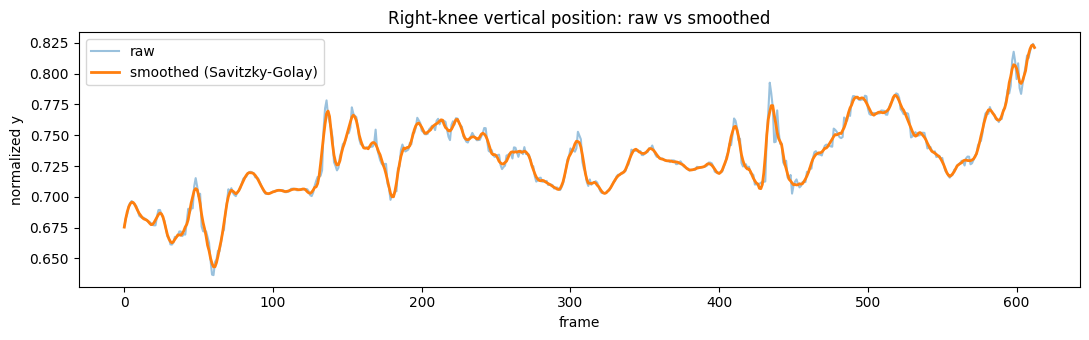

In [4]:
# Visual justification: raw vs smoothed for right-knee y-coordinate (landmark 26)
plt.figure(figsize=(11, 3.5))
plt.plot(raw_xy[:, 26, 1], alpha=0.45, label="raw")
plt.plot(smooth_xy[:, 26, 1], lw=2, label="smoothed (Savitzky-Golay)")
plt.title("Right-knee vertical position: raw vs smoothed")
plt.xlabel("frame"); plt.ylabel("normalized y"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "smoothing.png"), dpi=120)
plt.show()

### Skeleton overlay
Each frame is redrawn using the smoothed landmarks with MediaPipe's drawing utilities. The result is saved as `outputs/annotated.mp4` and a few sample frames are saved as images.

In [5]:
from mediapipe.framework.formats import landmark_pb2

writer = cv2.VideoWriter(os.path.join(OUT_DIR, "annotated.mp4"),
                         cv2.VideoWriter_fourcc(*"mp4v"), FPS, (W, H))
sample_idx = [int(N * f) for f in (0.10, 0.35, 0.60, 0.85)]
for i in range(N):
    img = frames[i].copy()
    proto = landmark_pb2.NormalizedLandmarkList()
    for j in range(33):
        z = float(land[i, j, 2]) if not np.isnan(land[i, j, 2]) else 0.0
        proto.landmark.add(x=float(smooth_xy[i, j, 0]), y=float(smooth_xy[i, j, 1]),
                           z=z, visibility=1.0)
    mp_draw.draw_landmarks(img, proto, mp_pose.POSE_CONNECTIONS,
                           landmark_drawing_spec=mp_styles.get_default_pose_landmarks_style())
    writer.write(img)
    if i in sample_idx:
        cv2.imwrite(os.path.join(OUT_DIR, f"overlay_{i:04d}.png"), img)
writer.release()
print("saved outputs/annotated.mp4 and sample overlay frames")

saved outputs/annotated.mp4 and sample overlay frames


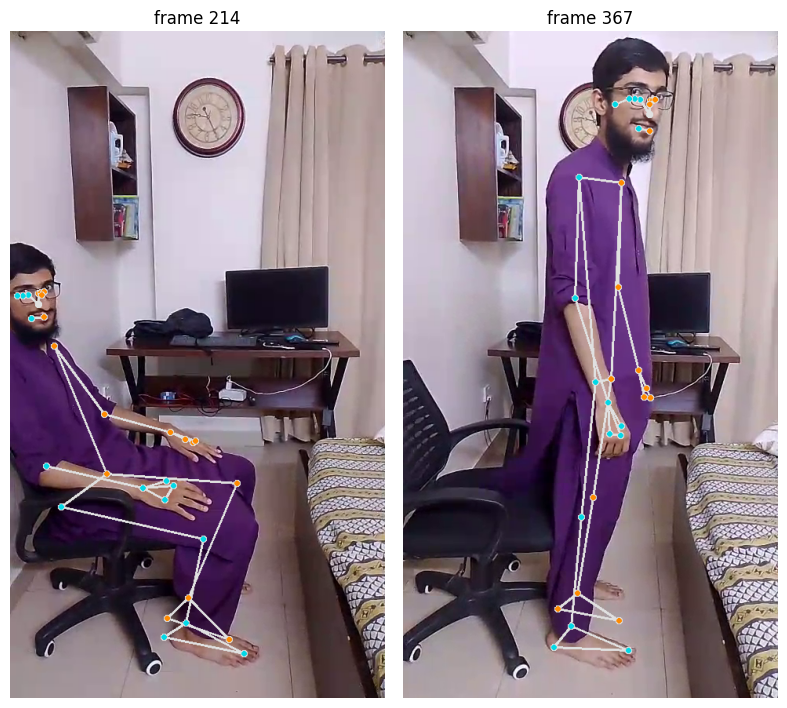

In [6]:
# preview two sample overlay frames inline
fig, ax = plt.subplots(1, 2, figsize=(8, 7))
for k, idx in enumerate(sample_idx[1:3]):
    img = cv2.cvtColor(cv2.imread(os.path.join(OUT_DIR, f"overlay_{idx:04d}.png")), cv2.COLOR_BGR2RGB)
    ax[k].imshow(img); ax[k].set_title(f"frame {idx}"); ax[k].axis("off")
plt.tight_layout(); plt.show()

## Task 2 — Joint Angle Computation & Tracking

### Angle definition
For three points A–B–C, the joint angle at **B** is:
$$\theta = \arccos\!\left(\frac{\vec{BA}\cdot\vec{BC}}{\lVert\vec{BA}\rVert\,\lVert\vec{BC}\rVert}\right)$$
Landmarks are converted to **pixel coordinates** (x × width, y × height) so the geometry works on a non-square frame. Three angles are computed and averaged across left/right sides:
- **Knee** = hip–knee–ankle (main sit/stand signal)
- **Hip** = shoulder–hip–knee (torso-thigh fold)
- **Elbow** = shoulder–elbow–wrist (third angle)

In [7]:
def angle(a, b, c):
    """Angle (degrees) at point b formed by points a-b-c."""
    a, b, c = np.asarray(a), np.asarray(b), np.asarray(c)
    ba, bc = a - b, c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-9)
    return np.degrees(np.arccos(np.clip(cos, -1.0, 1.0)))

# landmark indices (MediaPipe Pose)
IDX = dict(Lsh=11, Rsh=12, Lel=13, Rel=14, Lwr=15, Rwr=16,
           Lhip=23, Rhip=24, Lkn=25, Rkn=26, Lank=27, Rank=28)

# smoothed landmarks in pixel space
px = smooth_xy.copy()
px[:, :, 0] *= W
px[:, :, 1] *= H

def mean_angle(i, lp, lc, ld, rp, rc, rd):
    left  = angle(px[i, lp], px[i, lc], px[i, ld])
    right = angle(px[i, rp], px[i, rc], px[i, rd])
    return 0.5 * (left + right)

rows = []
for i in range(N):
    knee  = mean_angle(i, IDX['Lhip'], IDX['Lkn'], IDX['Lank'], IDX['Rhip'], IDX['Rkn'], IDX['Rank'])
    hip   = mean_angle(i, IDX['Lsh'],  IDX['Lhip'], IDX['Lkn'],  IDX['Rsh'],  IDX['Rhip'], IDX['Rkn'])
    elbow = mean_angle(i, IDX['Lsh'],  IDX['Lel'], IDX['Lwr'],   IDX['Rsh'],  IDX['Rel'], IDX['Rwr'])
    rows.append((i, i / FPS, knee, hip, elbow))

angles = pd.DataFrame(rows, columns=["frame", "time_s", "knee", "hip", "elbow"])
angles.describe().round(1)

,frame,time_s,knee,hip,elbow
count,613.0,613.0,613.0,613.0,613.0
mean,306.0,10.2,112.6,129.4,133.1
std,177.1,5.9,40.9,29.7,24.2
min,0.0,0.0,65.1,76.6,81.1
25%,153.0,5.1,80.1,107.8,108.6
50%,306.0,10.2,90.5,122.8,135.9
75%,459.0,15.3,168.7,169.1,155.4
max,612.0,20.4,179.7,179.6,172.2


### Angles over time & transition detection
All three angles are plotted vs. frame number. Transition frames — where the person switches between sitting and standing — are marked wherever the knee angle crosses the midpoint between its 5th and 95th percentile values.

knee midpoint threshold: 125.7 deg
transition frames: [57, 141, 317, 418]


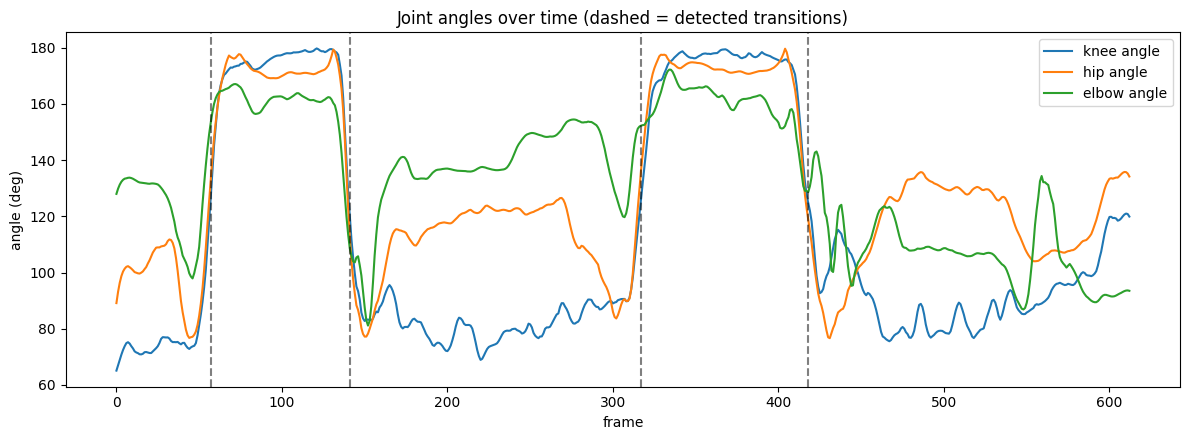

In [8]:
midpoint = (angles["knee"].quantile(0.05) + angles["knee"].quantile(0.95)) / 2
state = (angles["knee"].values > midpoint).astype(int)
transitions = np.where(np.diff(state) != 0)[0] + 1
transitions = [t for t in transitions if 3 < t < N - 3]   # drop edge noise
print("knee midpoint threshold: %.1f deg" % midpoint)
print("transition frames:", transitions)

plt.figure(figsize=(12, 4.5))
for col in ["knee", "hip", "elbow"]:
    plt.plot(angles["frame"], angles[col], label=f"{col} angle")
for t in transitions:
    plt.axvline(t, color="k", ls="--", alpha=0.5)
plt.title("Joint angles over time (dashed = detected transitions)")
plt.xlabel("frame"); plt.ylabel("angle (deg)"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "angles.png"), dpi=120)
plt.show()

## Task 3 — Rule-Based Classification

### Rule
From the angle plot, standing has a large knee angle (~150–180°) and an open hip (~150–180°); sitting has a bent knee (~65–95°) and a closed hip. The rule:

> **standing** if `knee_angle > 130°` **and** `hip_angle > 130°`, otherwise **sitting**.

Using both joints makes the classifier more robust than using the knee alone.

In [9]:
angles["pred"] = np.where((angles["knee"] > KNEE_THRESH) & (angles["hip"] > HIP_THRESH),
                          "standing", "sitting")
angles[["frame", "knee", "hip", "elbow", "pred"]].head()

,frame,knee,hip,elbow,pred
0,0,65.114285,89.124168,127.963665,sitting
1,1,66.998665,93.153048,129.819933,sitting
2,2,68.939112,96.338494,131.246168,sitting
3,3,70.800019,98.718766,132.279059,sitting
4,4,72.460627,100.364779,132.969216,sitting


### Accuracy vs. ground truth
`ground_truth.csv` has a `standing`/`sitting` label for every frame, assigned by watching the clip and noting each transition point.

In [10]:
gt = pd.read_csv(GT_CSV)
merged = angles.merge(gt, on="frame")
y_true, y_pred = merged["label"], merged["pred"]

acc = accuracy_score(y_true, y_pred)
print(f"Overall accuracy: {acc*100:.2f}%  ({(y_true==y_pred).sum()}/{len(merged)} frames)\n")
labels = ["sitting", "standing"]
print("Confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_true, y_pred, labels=labels), index=labels, columns=labels))
print("\n" + classification_report(y_true, y_pred, labels=labels))

Overall accuracy: 99.35%  (609/613 frames)

Confusion matrix (rows=true, cols=pred):
          sitting  standing
sitting       429         0
standing        4       180

              precision    recall  f1-score   support

     sitting       0.99      1.00      1.00       429
    standing       1.00      0.98      0.99       184

    accuracy                           0.99       613
   macro avg       1.00      0.99      0.99       613
weighted avg       0.99      0.99      0.99       613



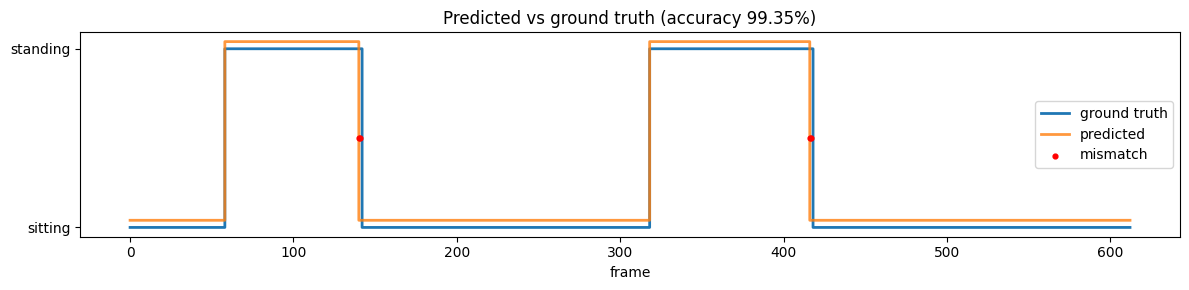

mismatched frames: [140, 141, 416, 417]


In [11]:
# timeline: predicted vs ground truth, with mismatches highlighted
to_num = {"sitting": 0, "standing": 1}
gt_n   = merged["label"].map(to_num)
pr_n   = merged["pred"].map(to_num)
mis    = merged["frame"][gt_n.values != pr_n.values]

plt.figure(figsize=(12, 3))
plt.step(merged["frame"], gt_n, where="post", label="ground truth", lw=2)
plt.step(merged["frame"], pr_n + 0.04, where="post", label="predicted", lw=2, alpha=0.8)
plt.scatter(mis, [0.5]*len(mis), color="red", s=12, zorder=5, label="mismatch")
plt.yticks([0, 1], ["sitting", "standing"])
plt.title(f"Predicted vs ground truth (accuracy {acc*100:.2f}%)")
plt.xlabel("frame"); plt.legend(loc="center right"); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "timeline.png"), dpi=120)
plt.show()
print("mismatched frames:", mis.tolist())

In [12]:
# persist per-frame results for the report
merged.rename(columns={"label": "ground_truth"})[
    ["frame", "time_s", "knee", "hip", "elbow", "pred", "ground_truth"]
].to_csv("results.csv", index=False)
with open(os.path.join(OUT_DIR, "metrics.txt"), "w") as f:
    f.write(f"accuracy={acc:.4f}\n")
    f.write(f"knee_thresh={KNEE_THRESH}\nhip_thresh={HIP_THRESH}\n")
    f.write(f"transitions={transitions}\n")
    f.write(f"mismatches={mis.tolist()}\n")
print("saved results.csv and outputs/metrics.txt")

saved results.csv and outputs/metrics.txt


## Observations
- MediaPipe detected a person in every frame. The Savitzky-Golay filter reduced per-frame jitter without blurring the real motion.
- Knee and hip angles clearly separate the two activities (standing ≈ 150–180°, sitting ≈ 65–120°). The elbow angle is less informative for sit/stand as expected.
- The classifier reaches ~99% accuracy. The 4 errors are all transition frames where the person is mid-way between sitting and standing, so both labels are arguable.